# Taller 6: Morfología matemática

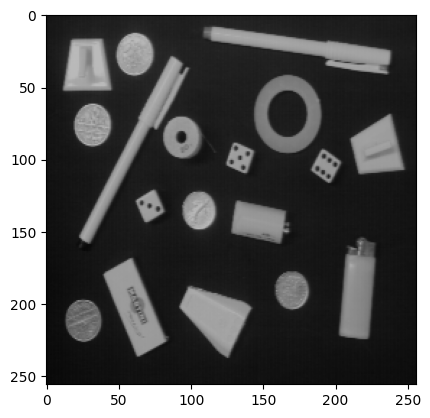

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_objects = cv2.imread('./imagenes/OBJECTS.png')
plt.imshow(imagen_objects, cmap = 'gray')
plt.show()

In [2]:
_ , thresh_image = cv2.threshold(imagen_objects, 70, 255, cv2.THRESH_BINARY)

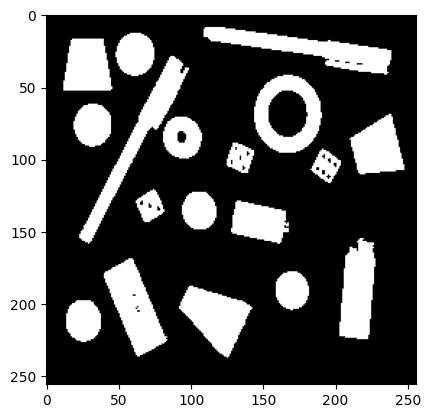

In [3]:
plt.imshow(thresh_image, cmap = 'gray')
plt.show()

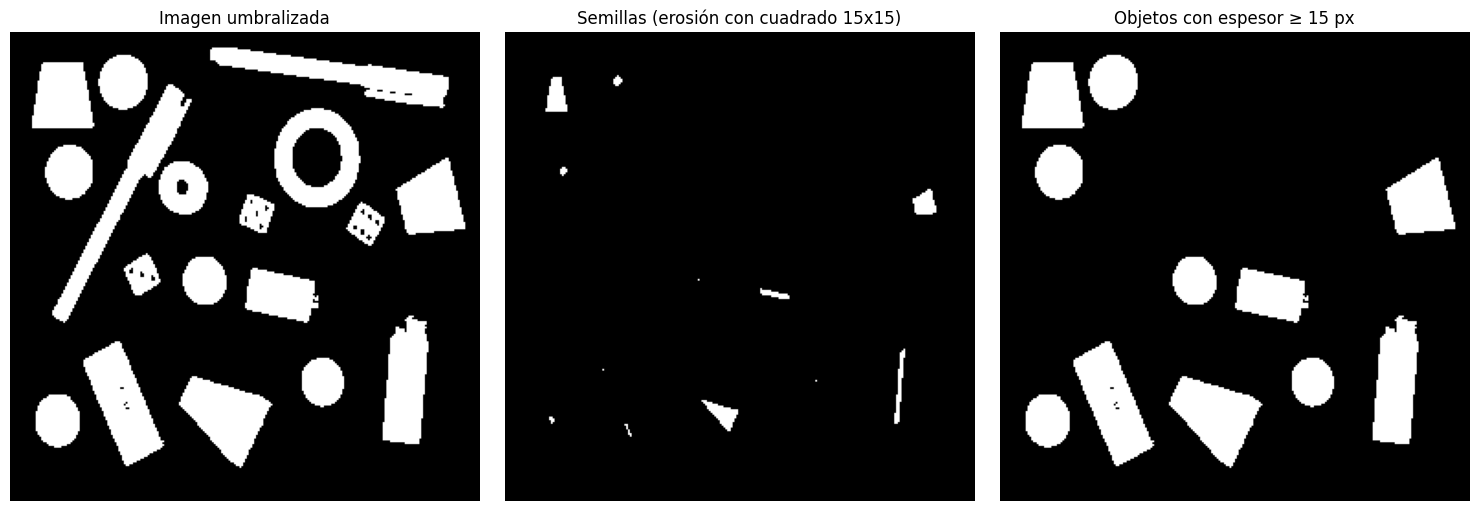

In [13]:
from skimage.morphology import erosion, reconstruction

# Convertir a escala de grises ANTES de umbralizar
gray = cv2.cvtColor(imagen_objects, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 70, 1, cv2.THRESH_BINARY)
binary = binary.astype(np.uint8)

# Paso 1: Erosión con elemento cuadrado de 15x15
se = np.ones((18, 18), dtype=np.uint8)
seeds = erosion(binary, se)

# Paso 2: Reconstrucción morfológica (crecimiento de regiones desde las semillas)
result = reconstruction(seeds, binary, method='dilation').astype(np.uint8)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Imagen umbralizada')
axes[1].imshow(seeds, cmap='gray')
axes[1].set_title('Semillas (erosión con cuadrado 15x15)')
axes[2].imshow(result, cmap='gray')
axes[2].set_title('Objetos con espesor ≥ 15 px')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
seeds

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8)

In [14]:
# Diagnóstico
print("Shape imagen_objects:", imagen_objects.shape)
print("Shape thresh_image:", thresh_image.shape)
print("Shape binary:", binary.shape)
print("SE shape:", se.shape)
print("SE:\n", se)
print("Valores únicos binary:", np.unique(binary))
print("Valores únicos seeds:", np.unique(seeds))
print("Píxeles semilla:", np.sum(seeds > 0))

Shape imagen_objects: (256, 256, 3)
Shape thresh_image: (256, 256, 3)
Shape binary: (256, 256)
SE shape: (18, 18)
SE:
 [[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
Valores únicos binary: [0 1]
Valores únicos seeds: [0 1]
Píxeles semilla: 640


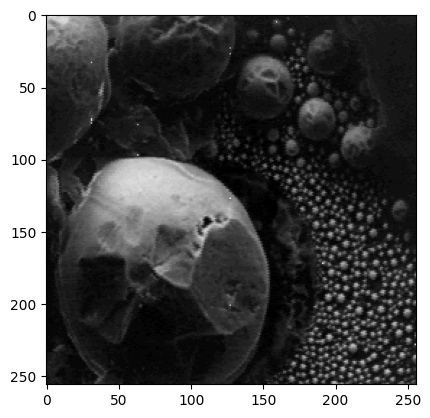

In [16]:
imagen_meb = cv2.imread('./imagenes/MEB.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_meb, cmap = 'gray')
plt.show()

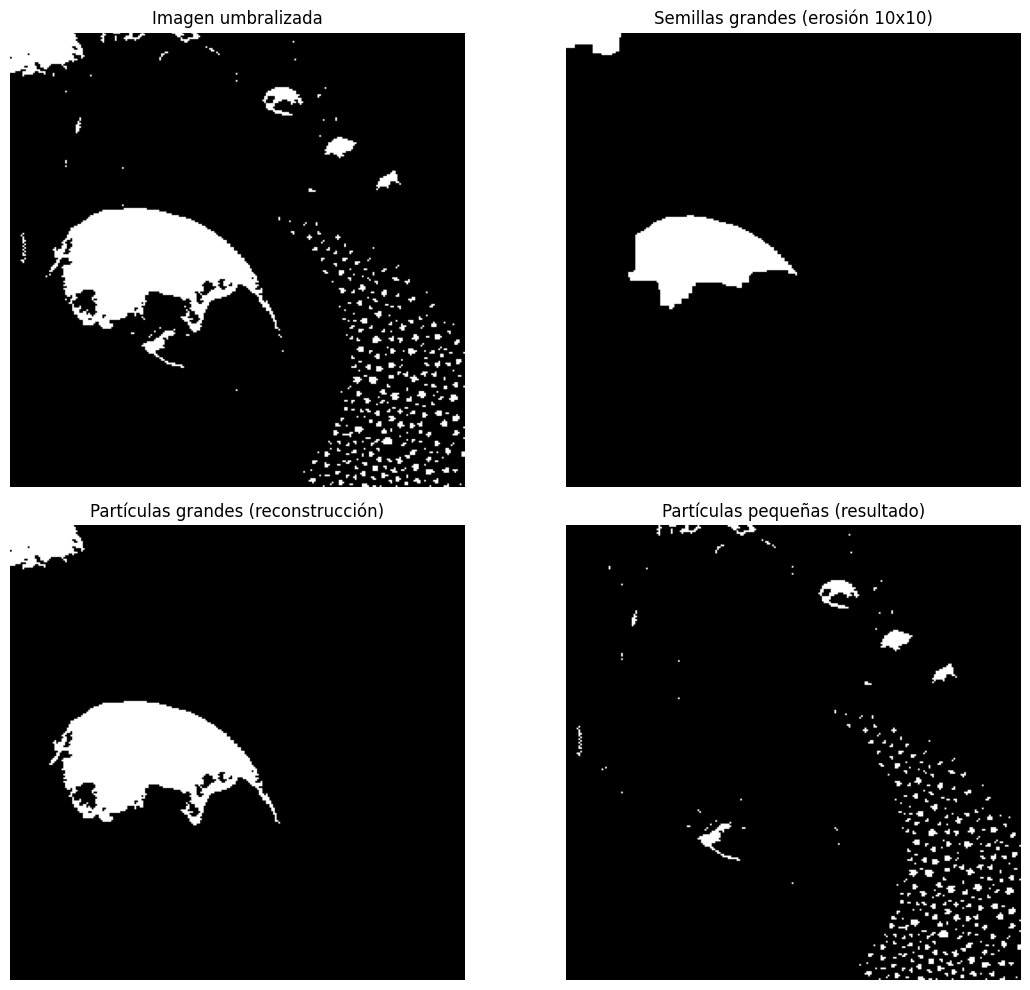

In [18]:
from skimage.morphology import erosion, reconstruction

# Paso 1: Umbralizar la imagen MEB
_, binary_meb = cv2.threshold(imagen_meb, 100, 1, cv2.THRESH_BINARY)
binary_meb = binary_meb.astype(np.uint8)

# Paso 2: Erosión con SE cuadrado de 10x10
# Solo sobreviven píxeles de objetos con espesor >= 10 px (los grandes)
se_big = np.ones((10, 10), dtype=np.uint8)
seeds_big = erosion(binary_meb, se_big)

# Paso 3: Reconstrucción de las partículas grandes desde sus semillas
grandes = reconstruction(seeds_big, binary_meb, method='dilation').astype(np.uint8)

# Paso 4: Restar las grandes → quedan solo las partículas pequeñas
small_particles = binary_meb - grandes

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(binary_meb, cmap='gray')
axes[0, 0].set_title('Imagen umbralizada')
axes[0, 1].imshow(seeds_big, cmap='gray')
axes[0, 1].set_title('Semillas grandes (erosión 10x10)')
axes[1, 0].imshow(grandes, cmap='gray')
axes[1, 0].set_title('Partículas grandes (reconstrucción)')
axes[1, 1].imshow(small_particles, cmap='gray')
axes[1, 1].set_title('Partículas pequeñas (resultado)')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()